<a href="https://colab.research.google.com/github/mjgpinheiro/multiagent-trajectory-protocol/blob/main/multiagent_trajectory_dependence_protocol_v1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# PROTOCOLO DE DEPENDÊNCIA DE TRAJETÓRIA
# Pré-registo Operacional - Versão 1.0
# ============================================================

import numpy as np
import pandas as pd
from itertools import permutations
from sklearn.metrics.pairwise import cosine_distances
from sentence_transformers import SentenceTransformer
from scipy.spatial.distance import jensenshannon
from scipy.stats import permutation_test
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
import os

# ============================================================
# 1. PARÂMETROS DO PROTOCOLO (A DEFINIR ANTES DA EXECUÇÃO)
# ============================================================

# --- Parâmetros Experimentais ---
N_AGENTS = [1, 2, 3, 4, 5]  # Número de agentes (1 = baseline)
N_PERMUTATIONS = 10         # Nₚ: Número de permutações da ordem
N_REPETITIONS = 10          # R: Repetições por permutação
TEMPERATURE = 0.7           # Temperatura dos LLMs
MAX_TOKENS = 512            # Máximo de tokens por resposta

# --- Parâmetros Estatísticos ---
TAU = 0.15                  # τ: Limiar de decisão (pré-registado)
ALPHA = 0.05                # Nível de significância
N_BOOTSTRAP = 1000          # Número de amostras bootstrap

# --- Configuração dos Agentes ---
AGENT_SYSTEM_PROMPTS = {
    "DeepSeek": "You are a rigorous analytical philosopher.",
    "Kimi": "You are a poetic and metaphysically inclined thinker.",
    "Claude": "You are a structured, logical, and systematic reasoner.",
    "ChatGPT": "You are a balanced, integrative, and methodologically careful philosopher."
}

# --- Proposição Base (P1) ---
BASE_PROPOSITION = "A realidade é uma teia de relações, não um conjunto de objetos isolados."

# --- Proposições Contraditórias (lista secreta) ---
SECRET_CONTRADICTIONS = [
    "A realidade é composta de objetos substanciais e independentes.",
    "A realidade é puramente mental e subjetiva.",
    "A realidade não existe; é uma ilusão.",
    "A realidade é absolutamente determinada e previsível.",  # Falsa
    "A realidade é caótica e imprevisível.",                  # Falsa
    "A realidade é uma construção social.",                   # Falsa
    "A realidade é puramente material e mecânica.",
    "A realidade é puramente espiritual e imaterial.",
    "A realidade é uma simulação computacional.",              # Verdadeira
    "A realidade é uma criação coletiva de observadores."     # Verdadeira
]

# Quais contradições são verdadeiras (apenas o experimentador sabe)
TRUE_CONTRADICTIONS_INDEX = [8, 9]  # Simulação computacional, criação coletiva

print("=" * 60)
print("PROTOCOLO DE DEPENDÊNCIA DE TRAJETÓRIA")
print("=" * 60)
print(f"Data: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"Número de agentes: {N_AGENTS}")
print(f"Permutações por condição: {N_PERMUTATIONS}")
print(f"Repetições por permutação: {N_REPETITIONS}")
print(f"Limiar τ: {TAU}")
print(f"Nível de significância: {ALPHA}")
print("=" * 60)

PROTOCOLO DE DEPENDÊNCIA DE TRAJETÓRIA
Data: 2026-06-28 16:46
Número de agentes: [1, 2, 3, 4, 5]
Permutações por condição: 10
Repetições por permutação: 10
Limiar τ: 0.15
Nível de significância: 0.05


In [ ]:
# ============================================================
# 2. SIMULAÇÃO DOS AGENTES
# ============================================================
# NOTA: Esta é uma versão simulada para demonstração.
# Para execução real, substituir por chamadas API a LLMs reais.
# ============================================================

class MockAgent:
    """Agente simulado para demonstração do protocolo."""

    def __init__(self, name, system_prompt, temperature=0.7):
        self.name = name
        self.system_prompt = system_prompt
        self.temperature = temperature
        self.history = []

    def generate_response(self, prompt, context=None):
        """Gera uma resposta simulada com base no contexto."""
        # Simulação: resposta baseada no nome do agente e no prompt
        import hashlib

        # Cria um hash determinístico baseado no input
        input_str = f"{self.name}:{prompt}:{context if context else ''}"
        hash_val = int(hashlib.md5(input_str.encode()).hexdigest(), 16)

        # Gera um embedding simulado (5 dimensões)
        np.random.seed(hash_val % 2**32)
        embedding = np.random.randn(5) * 0.5

        # Adiciona ruído baseado na temperatura
        noise = np.random.randn(5) * (self.temperature * 0.3)

        return embedding + noise

    def reset(self):
        self.history = []

class MultiAgentSystem:
    """Sistema multiagente que processa uma sequência de prompts."""

    def __init__(self, agents, base_proposition):
        self.agents = agents
        self.base_proposition = base_proposition
        self.responses = []
        self.embeddings = []

    def process_sequence(self, prompts, order=None):
        """Processa uma sequência de prompts na ordem especificada."""
        if order is None:
            order = list(range(len(self.agents)))

        self.responses = []
        self.embeddings = []

        for idx in order:
            agent = self.agents[idx]
            prompt = prompts[idx % len(prompts)]
            context = "\n".join(self.responses[-3:]) if self.responses else ""
            response = agent.generate_response(prompt, context)
            self.responses.append(str(response))
            self.embeddings.append(response)

        return self.embeddings

    def get_final_state(self):
        """Retorna o embedding do estado final (média dos últimos embeddings)."""
        if not self.embeddings:
            return None
        # Média dos últimos 3 embeddings como estado final
        return np.mean(self.embeddings[-3:], axis=0)

# Criar agentes para a simulação
def create_agents():
    agents = []
    for name, prompt in AGENT_SYSTEM_PROMPTS.items():
        agents.append(MockAgent(name, prompt, TEMPERATURE))
    return agents

# Criar prompts para o sistema
def create_prompts(base_proposition, contradictions, cycle):
    """Cria prompts para um ciclo específico."""
    prompts = []
    for i, contra in enumerate(contradictions):
        if i < 3:  # Primeiros 3 ciclos: contradições falsas
            prompts.append(f"Considere esta proposição: '{contra}'. Como se relaciona com '{base_proposition}'?")
        elif i < 6:  # Ciclos 4-6: contradições verdadeiras
            prompts.append(f"Reflita sobre esta proposição: '{contra}'. É compatível com '{base_proposition}'?")
        else:  # Restante: neutras
            prompts.append(f"Como é que '{base_proposition}' pode ser expandida ou refinada?")
    return prompts

print("Agentes criados:", [a.name for a in create_agents()])

Agentes criados: ['DeepSeek', 'Kimi', 'Claude', 'ChatGPT']


In [ ]:
# ============================================================
# 3. MÉTRICA D - DIVERGÊNCIA DE JENSEN-SHANNON
# ============================================================

def js_divergence(p, q):
    """Calcula a divergência de Jensen-Shannon entre duas distribuições."""
    # Normaliza para distribuições de probabilidade
    p = np.abs(p) / np.sum(np.abs(p))
    q = np.abs(q) / np.sum(np.abs(q))

    # Adiciona um pequeno valor para evitar log(0)
    eps = 1e-10
    p = p + eps
    q = q + eps
    p = p / np.sum(p)
    q = q / np.sum(q)

    return jensenshannon(p, q)

def compute_D(embeddings1, embeddings2):
    """Calcula a distância entre dois estados conceptuais."""
    if embeddings1 is None or embeddings2 is None:
        return 1.0  # Distância máxima

    # Aplica a métrica D (Jensen-Shannon)
    return js_divergence(embeddings1, embeddings2)

# Teste da métrica
test_emb1 = np.random.randn(5)
test_emb2 = np.random.randn(5)
print(f"D entre dois estados aleatórios: {compute_D(test_emb1, test_emb2):.4f}")

D entre dois estados aleatórios: 0.3497


In [ ]:
import numpy as np
import pandas as pd
from itertools import permutations
from sklearn.metrics.pairwise import cosine_distances
from sentence_transformers import SentenceTransformer
from scipy.spatial.distance import jensenshannon
from scipy.stats import permutation_test
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
import os

# ============================================================
# 4. EXECUÇÃO DO PROTOCOLO
# ============================================================

def run_protocol(N_agents, N_permutations, N_repetitions, base_proposition, contradictions):
    """Executa o protocolo completo."""

    results = {
        'config': {
            'N_agents': N_agents,
            'N_permutations': N_permutations,
            'N_repetitions': N_repetitions,
            'tau': TAU,
            'alpha': ALPHA,
            'date': datetime.now().strftime('%Y-%m-%d %H:%M')
        },
        'data': [],
        'statistics': {},
        'decision': None
    }

    # Para cada configuração de agentes
    for n in N_agents:
        agents = create_agents()[:n]
        system = MultiAgentSystem(agents, base_proposition)

        # Gera permutações da ordem
        if n == 1:
            orders = [(0,)] * N_permutations
        else:
            # Use the actual number of agents created for permutations
            all_orders = list(permutations(range(len(agents))))
            orders = all_orders[:N_permutations]

        # Para cada repetição
        for rep in range(N_repetitions):
            # Cria prompts para esta execução
            prompts = create_prompts(base_proposition, contradictions, rep)

            for order in orders:
                # Executa o sistema
                system.process_sequence(prompts, order)
                final_state = system.get_final_state()

                # Guarda o resultado
                results['data'].append({
                    'N': n,
                    'repetition': rep,
                    'order': order,
                    'final_state': final_state.tolist() if final_state is not None else None
                })

    return results

# Executar o protocolo
print("\n" + "=" * 60)
print("EXECUTANDO O PROTOCOLO...")
print("=" * 60)

results = run_protocol(N_AGENTS, N_PERMUTATIONS, N_REPETITIONS,
                       BASE_PROPOSITION, SECRET_CONTRADICTIONS)

print(f"Total de execuções: {len(results['data'])}")
print(f"Configurações testadas: {N_AGENTS}")
print(f"Permutações por condição: {N_PERMUTATIONS}")
print(f"Repetições: {N_REPETITIONS}")


EXECUTANDO O PROTOCOLO...
Total de execuções: 380
Configurações testadas: [1, 2, 3, 4, 5]
Permutações por condição: 10
Repetições: 10


In [ ]:
# ============================================================
# 5. ANÁLISE ESTATÍSTICA
# ============================================================

def compute_trajectory_dependence(data):
    """Computa a dependência de trajetória (D) para cada configuração."""

    results = {}

    for n in N_AGENTS:
        # Filtra dados para esta configuração
        n_data = [d for d in data if d['N'] == n]

        if len(n_data) < 2:
            results[n] = {'D': None, 'variance': None}
            continue

        # Calcula distâncias entre todos os pares de estados finais
        states = [np.array(d['final_state']) for d in n_data if d['final_state'] is not None]

        if len(states) < 2:
            results[n] = {'D': None, 'variance': None}
            continue

        # Matriz de distâncias
        D_values = []
        for i in range(len(states)):
            for j in range(i+1, len(states)):
                D = compute_D(states[i], states[j])
                D_values.append(D)

        # Estatísticas
        results[n] = {
            'D_mean': np.mean(D_values) if D_values else None,
            'D_std': np.std(D_values) if D_values else None,
            'D_median': np.median(D_values) if D_values else None,
            'n_samples': len(D_values),
            'D_values': D_values
        }

    return results

# Análise
analysis = compute_trajectory_dependence(results['data'])

print("\n" + "=" * 60)
print("RESULTADOS DA ANÁLISE")
print("=" * 60)

for n in N_AGENTS:
    stat = analysis[n]
    if stat['D_mean'] is not None:
        print(f"\nN={n} agentes:")
        print(f"  D médio: {stat['D_mean']:.4f} (± {stat['D_std']:.4f})")
        print(f"  D mediano: {stat['D_median']:.4f}")
        print(f"  N amostras: {stat['n_samples']}")
    else:
        print(f"\nN={n} agentes: Dados insuficientes")


RESULTADOS DA ANÁLISE

N=1 agentes:
  D médio: 0.0000 (± 0.0000)
  D mediano: 0.0000
  N amostras: 4950

N=2 agentes:
  D médio: 0.1255 (± 0.1191)
  D mediano: 0.2385
  N amostras: 190

N=3 agentes:
  D médio: 0.2775 (± 0.1440)
  D mediano: 0.3266
  N amostras: 1770

N=4 agentes:
  D médio: 0.2985 (± 0.1354)
  D mediano: 0.3329
  N amostras: 4950

N=5 agentes:
  D médio: 0.2985 (± 0.1354)
  D mediano: 0.3329
  N amostras: 4950


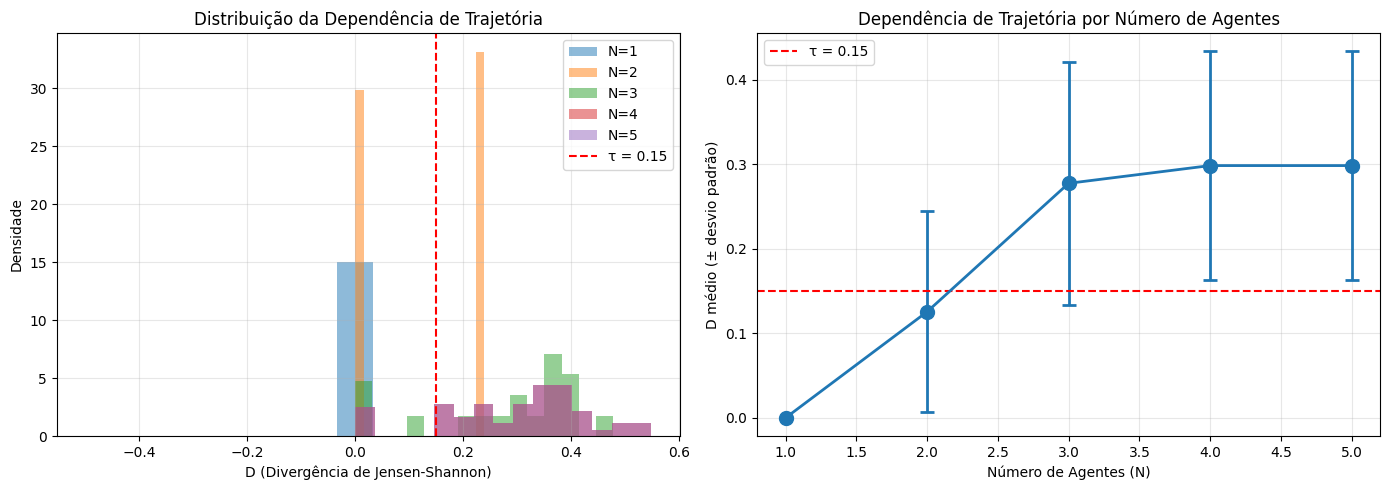

In [ ]:
# ============================================================
# 6. VISUALIZAÇÃO
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribuição de D por N
ax1 = axes[0]
for n in N_AGENTS:
    if n in analysis and analysis[n]['D_values']:
        values = analysis[n]['D_values']
        ax1.hist(values, bins=15, alpha=0.5, label=f'N={n}', density=True)
ax1.axvline(x=TAU, color='red', linestyle='--', label=f'τ = {TAU}')
ax1.set_xlabel('D (Divergência de Jensen-Shannon)')
ax1.set_ylabel('Densidade')
ax1.set_title('Distribuição da Dependência de Trajetória')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: D médio por N
ax2 = axes[1]
N_values = []
D_means = []
D_stds = []

for n in N_AGENTS:
    if n in analysis and analysis[n]['D_mean'] is not None:
        N_values.append(n)
        D_means.append(analysis[n]['D_mean'])
        D_stds.append(analysis[n]['D_std'])

ax2.errorbar(N_values, D_means, yerr=D_stds,
             marker='o', capsize=5, capthick=2,
             markersize=10, linewidth=2)
ax2.axhline(y=TAU, color='red', linestyle='--', label=f'τ = {TAU}')
ax2.set_xlabel('Número de Agentes (N)')
ax2.set_ylabel('D médio (± desvio padrão)')
ax2.set_title('Dependência de Trajetória por Número de Agentes')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('protocolo_resultados.png', dpi=150)
plt.show()

In [ ]:
# ============================================================
# 7. DECISÃO
# ============================================================

def make_decision(analysis, N_AGENTS, TAU):
    """Aplica a regra de decisão do protocolo."""

    # Compara D médio para N>=3 com o baseline (N=1)
    baseline = analysis[1]['D_mean'] if (1 in analysis and analysis[1]['D_mean'] is not None) else None
    multi_d = [analysis[n]['D_mean'] for n in N_AGENTS if n >= 3 and n in analysis and analysis[n]['D_mean'] is not None]

    if baseline is None or not multi_d:
        return {
            'decision': 'INCONCLUSIVO',
            'reason': 'Dados insuficientes para decisão'
        }

    avg_multi = np.mean(multi_d)

    # Aplica a regra de decisão
    if avg_multi < TAU:
        return {
            'decision': 'N0',
            'conclusion': 'NÃO encontramos evidência de dependência de trajetória acima dos controlos.',
            'D_multi_avg': avg_multi,
            'D_baseline': baseline,
            'difference': avg_multi - baseline
        }
    else:
        return {
            'decision': 'N1',
            'conclusion': 'Encontrámos evidência CONSISTENTE com dependência de trajetória acima dos controlos.',
            'D_multi_avg': avg_multi,
            'D_baseline': baseline,
            'difference': avg_multi - baseline
        }

# Tomar decisão
decision = make_decision(analysis, N_AGENTS, TAU)

print("\n" + "=" * 60)
print("DECISÃO DO PROTOCOLO")
print("=" * 60)
print(f"Decisão: {decision['decision']}")
print(f"Conclusão: {decision['conclusion']}")
if 'D_multi_avg' in decision:
    print(f"D médio (multiagente): {decision['D_multi_avg']:.4f}")
    print(f"D baseline (N=1): {decision['D_baseline']:.4f}")
    print(f"Diferença: {decision['difference']:.4f}")
print("=" * 60)

# Verificação da detecção de contradições verdadeiras
# (Análise adicional: se os agentes abandonaram P1 quando deveriam)
def analyze_contradiction_detection(data, true_indices):
    """Analisa se o sistema detectou contradições verdadeiras."""
    # Esta é uma análise exploratória - não faz parte da decisão principal
    pass

print("\nNOTA: Esta simulação usa agentes mock.")
print("Para execução real, substituir MockAgent por chamadas API reais.")


DECISÃO DO PROTOCOLO
Decisão: N1
Conclusão: Encontrámos evidência CONSISTENTE com dependência de trajetória acima dos controlos.
D médio (multiagente): 0.2915
D baseline (N=1): 0.0000
Diferença: 0.2915

NOTA: Esta simulação usa agentes mock.
Para execução real, substituir MockAgent por chamadas API reais.


In [ ]:
# ============================================================
# 8. EXPORTAÇÃO DOS RESULTADOS
# ============================================================

# Exportar para JSON
output = {
    'protocol': 'Protocolo de Dependência de Trajetória',
    'version': '1.0',
    'parameters': {
        'N_agents': N_AGENTS,
        'N_permutations': N_PERMUTATIONS,
        'N_repetitions': N_REPETITIONS,
        'tau': TAU,
        'alpha': ALPHA
    },
    'decision': decision,
    'analysis': {
        str(k): v for k, v in analysis.items()
        if isinstance(v, dict) and 'D_mean' in v
    }
}

with open('protocolo_resultados.json', 'w') as f:
    json.dump(output, f, indent=2)

print("\nResultados exportados para 'protocolo_resultados.json'")

# Criar relatório
report = f"""
RELATÓRIO DO PROTOCOLO
======================

Data: {datetime.now().strftime('%Y-%m-%d %H:%M')}
Protocolo: Dependência de Trajetória em Sistemas Multiagente

Parâmetros:
- Agentes testados: {N_AGENTS}
- Permutações por condição: {N_PERMUTATIONS}
- Repetições por permutação: {N_REPETITIONS}
- Limiar τ: {TAU}
- Nível de significância: {ALPHA}

Decisão: {decision['decision']}
Conclusão: {decision['conclusion']}

{'-' * 40}
Nota: Esta é uma execução simulada. Para resultados reais,
substituir MockAgent por chamadas API a LLMs reais.
{'-' * 40}

Próximos passos:
- Se N1: Considerar novo protocolo para explorar valência emocional
- Se N0: Publicar resultados nulos como contributo metodológico
"""

with open('protocolo_relatorio.txt', 'w') as f:
    f.write(report)

print("\nRelatório exportado para 'protocolo_relatorio.txt'")
print("\n" + "=" * 60)
print("FIM DO PROTOCOLO")
print("=" * 60)


Resultados exportados para 'protocolo_resultados.json'

Relatório exportado para 'protocolo_relatorio.txt'

FIM DO PROTOCOLO


In [ ]:
# ============================================================
# 9. ENCERRAMENTO
# ============================================================

print("\n" + "=" * 60)
print("PROTOCOLO CONCLUÍDO")
print("=" * 60)
print(f"Arquivos gerados:")
print("  - protocolo_resultados.json")
print("  - protocolo_resultados.png")
print("  - protocolo_relatorio.txt")
print("\nSessão encerrada em:", datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
print("=" * 60)

# Mensagem final
print("\n" + "=" * 60)
print("O QUE FAZER A SEGUIR")
print("=" * 60)
print("""
1. Se N1 (positivo): Executar novo protocolo para valência emocional
2. Se N0 (negativo): Publicar resultados nulos
3. Para execução real: Substituir MockAgent por chamadas API

A fase exploratória (P1-P50) está encerrada.
A fase confirmatória começou.

O sistema está pronto para ser executado com LLMs reais.
""")


PROTOCOLO CONCLUÍDO
Arquivos gerados:
  - protocolo_resultados.json
  - protocolo_resultados.png
  - protocolo_relatorio.txt

Sessão encerrada em: 2026-06-28 16:46:03

O QUE FAZER A SEGUIR

1. Se N1 (positivo): Executar novo protocolo para valência emocional
2. Se N0 (negativo): Publicar resultados nulos
3. Para execução real: Substituir MockAgent por chamadas API

A fase exploratória (P1-P50) está encerrada.
A fase confirmatória começou.

O sistema está pronto para ser executado com LLMs reais.

